# Activité 3 — Modélisation appliquée : projet CrediTrust Scoring

**Objectif métier** : CrediTrust est une institution de micro-crédit qui souhaite un outil
d'aide à la décision pour estimer le **risque** associé à une demande de prêt.

On reprend les mêmes outils que dans les notebooks précédents :
- l'EDA et le traitement des valeurs manquantes vus dans `nb_01` (histogrammes, boxplots,
  `pd.get_dummies` pour l'encodage, remplissage des valeurs manquantes),
- l'entraînement/évaluation de plusieurs modèles de classification vus dans `nb_02`
  (`train_test_split`, `StandardScaler`, KNN / Régression Logistique / SVM / Arbre de
  Décision / Random Forest, dictionnaires de prédictions et de métriques).

La différence ici : dans le crédit, un **Faux Négatif** (un dossier risqué prédit comme sûr)
coûte beaucoup plus cher qu'un Faux Positif (un bon dossier prédit comme risqué). On va donc
prêter une attention particulière au **rappel (recall)** sur la classe "risque".

Démarche pour la sélection du modèle : on entraîne **5 modèles** pour explorer plusieurs familles
d'algorithmes, puis on ne garde que les **3 meilleurs** (sur le rappel) pour l'analyse détaillée
(matrices de confusion, interprétabilité) et le choix du modèle optimal final.


## 1. Chargement et premier coup d'œil

Le fichier `loan_data.csv` est le jeu de données historique "Loan Prediction". Chaque ligne est une
demande de prêt, avec des informations sur le demandeur (revenus, situation familiale, historique de
crédit...) et le statut final `Loan_Status` (`Y` = prêt accordé, `N` = prêt refusé).

⚠️ Certaines lignes n'ont pas de `Loan_Status` renseigné : ce sont des dossiers pour lesquels on n'a
pas de décision historique. On ne peut ni les entraîner ni les évaluer dessus (on ne connaît pas la
bonne réponse), donc on les retire dès le départ.


In [1]:
# Bibliothèques standard pour manipuler les données et faire des graphiques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le fichier brut et afficher les premières lignes
df = pd.read_csv('../data/loan_data.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
# Nombre de lignes et de colonnes du fichier brut
df.shape


(981, 13)

In [3]:
# Noms des colonnes, types de données et nombre de valeurs non manquantes
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    str    
 1   Gender             957 non-null    str    
 2   Married            978 non-null    str    
 3   Dependents         956 non-null    str    
 4   Education          981 non-null    str    
 5   Self_Employed      926 non-null    str    
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 99.8 KB


In [4]:
# Compter les lignes où la cible (Loan_Status) est manquante -- inutilisables
print("Nombre de lignes sans Loan_Status connu :", df['Loan_Status'].isnull().sum())

# Retirer les lignes sans label connu, et retirer Loan_ID (identifiant unique, sans valeur prédictive)
df = df.dropna(subset=['Loan_Status']).drop(columns=['Loan_ID']).reset_index(drop=True)
print("Dimensions après nettoyage (Loan_Status connu, Loan_ID retiré) :", df.shape)
df.head()


Nombre de lignes sans Loan_Status connu : 367
Dimensions après nettoyage (Loan_Status connu, Loan_ID retiré) : (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Pourquoi retirer `Loan_ID`** : c'est un identifiant unique par dossier, il n'a aucune valeur
prédictive (comme vu dans nb_01, on ne garde que des variables qui ont un sens statistique).


## 2. Analyse exploratoire (EDA)

In [5]:
# Statistiques descriptives des colonnes numériques (moyenne, écart-type, min, max, quartiles)
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
# Statistiques descriptives des colonnes catégorielles (texte)
df.describe(include=['O'])


/var/folders/y2/5dcsv6wn2lsg2qp8860v8sxr0000gn/T/ipykernel_57810/3807727011.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['O'])


,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,599,614,582,614,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,489,398,345,480,500,233,422


In [7]:
# Valeurs manquantes par colonne
print("Valeurs manquantes par colonne :")
df.isnull().sum()


Valeurs manquantes par colonne :


Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Part de refus (N) : 31.3 %


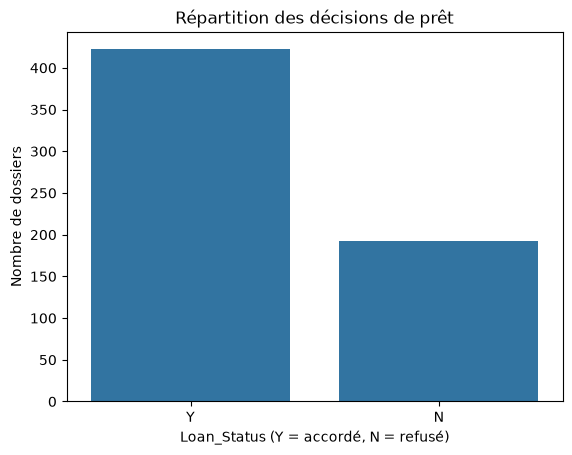

In [8]:
# Combien de prêts ont été accordés (Y) vs refusés (N)
target_counts = df['Loan_Status'].value_counts()
print(target_counts)
print()
print("Part de refus (N) :", round((target_counts['N'] / target_counts.sum()) * 100, 1), "%")

# Diagramme en barres de la répartition de la cible
sns.countplot(data=df, x='Loan_Status', order=['Y', 'N'])
plt.title("Répartition des décisions de prêt")
plt.xlabel("Loan_Status (Y = accordé, N = refusé)")
plt.ylabel("Nombre de dossiers")
plt.show()


**Observation** : les classes sont déséquilibrées (nettement plus de prêts accordés que de refus).
C'est important pour la suite : l'accuracy seule serait trompeuse (un modèle qui prédit toujours
"accordé" aurait déjà une bonne accuracy sans être utile). C'est pour ça qu'on va aussi regarder
précision, rappel et F1 sur la classe "risque".


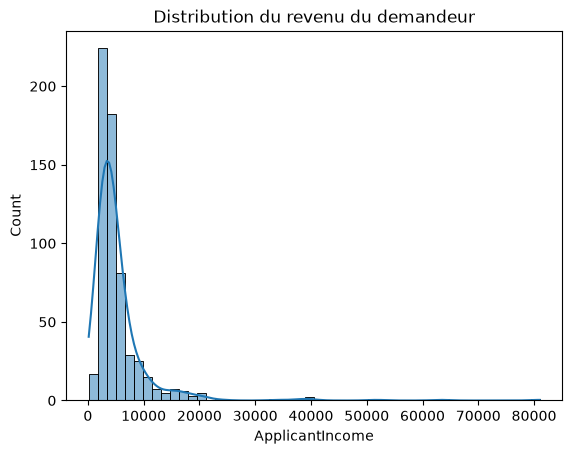

In [9]:
# Distribution du revenu du demandeur
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Distribution du revenu du demandeur")
plt.show()


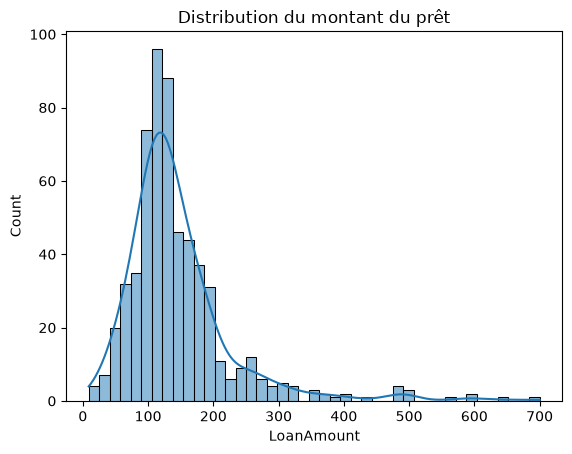

In [10]:
# Distribution du montant du prêt (valeurs manquantes retirées juste pour ce graphique)
sns.histplot(df['LoanAmount'].dropna(), kde=True)
plt.title("Distribution du montant du prêt")
plt.show()


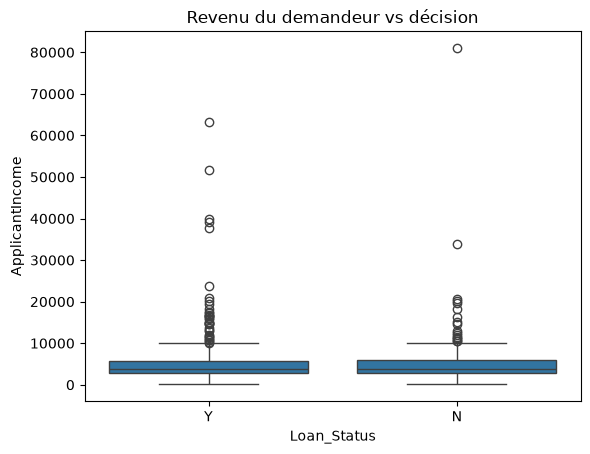

In [11]:
# Le revenu diffère-t-il entre prêts accordés et refusés ?
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, order=['Y', 'N'])
plt.title("Revenu du demandeur vs décision")
plt.show()


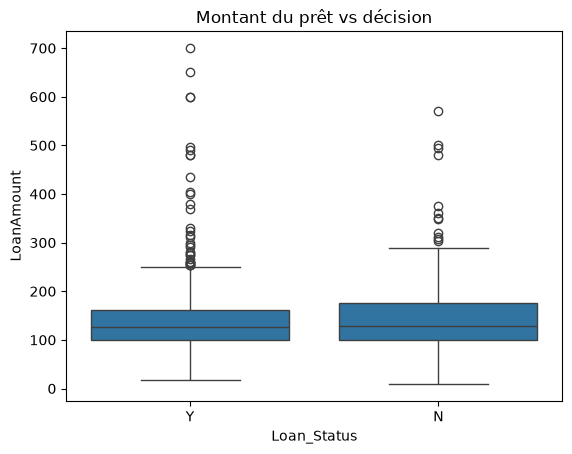

In [12]:
# Le montant du prêt diffère-t-il entre prêts accordés et refusés ?
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, order=['Y', 'N'])
plt.title("Montant du prêt vs décision")
plt.show()


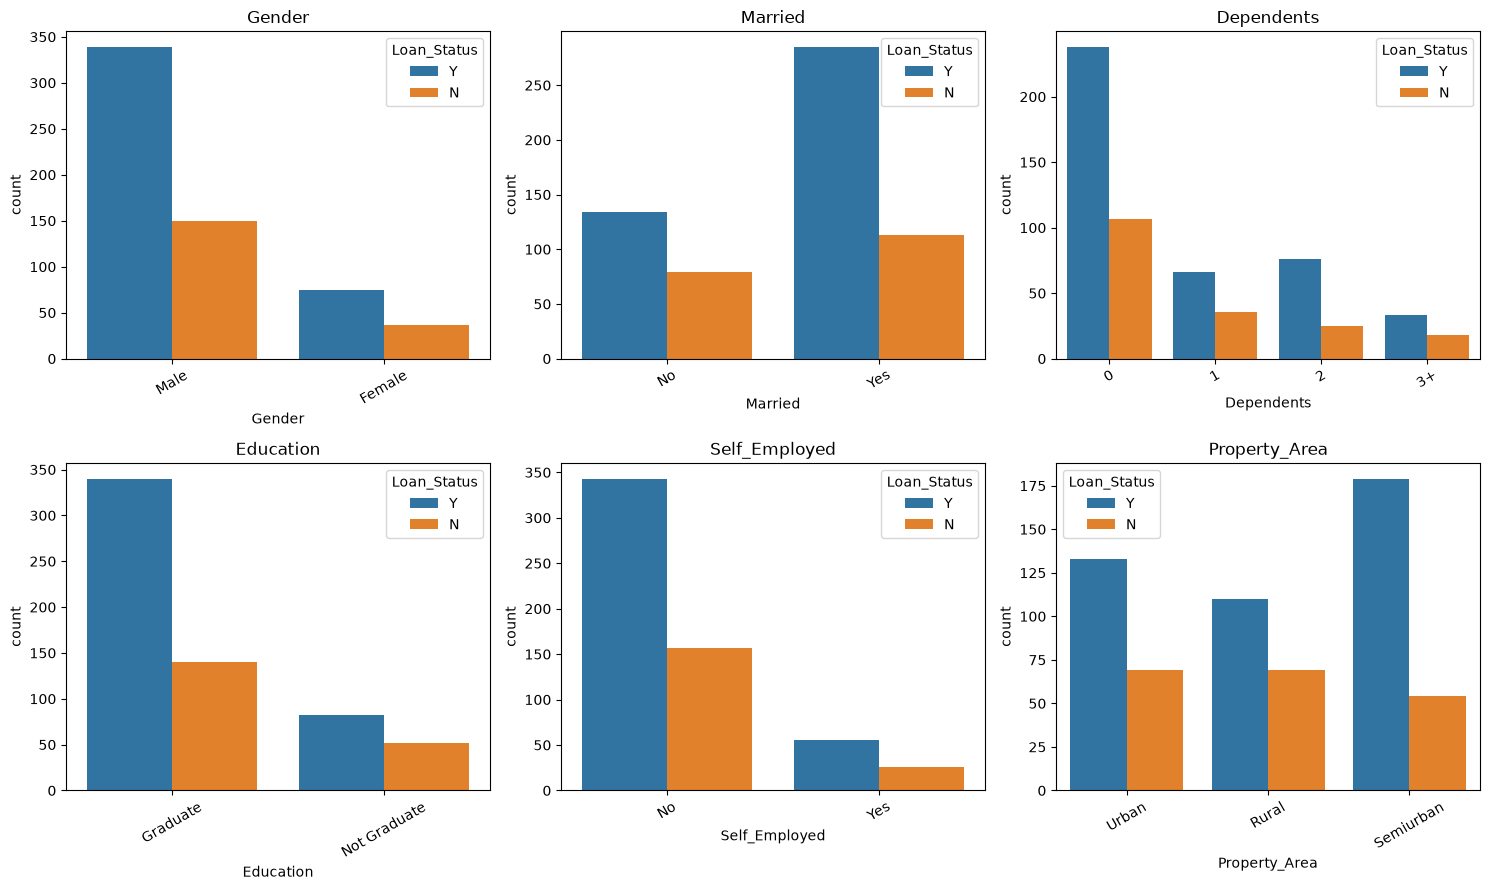

In [13]:
# Pour chaque colonne catégorielle, comparer sa distribution entre prêts accordés (Y) et refusés (N)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), categorical_cols):
    sns.countplot(data=df, x=col, hue='Loan_Status', hue_order=['Y', 'N'], ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


In [14]:
# Tableau croisé : pour chaque valeur de Credit_History, quel % de prêts accordés/refusés ?
credit_ct = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100
print("Taux d'accord/refus selon l'historique de crédit (%) :")
credit_ct.round(1)


Taux d'accord/refus selon l'historique de crédit (%) :


Loan_Status,N,Y
Credit_History,,
0.0,92.1,7.9
1.0,20.4,79.6


**Facteur de risque majeur qui ressort** : `Credit_History` (le demandeur a-t-il déjà remboursé un
crédit correctement par le passé, 1 = oui, 0 = non). Le taux de refus explose quand
`Credit_History = 0`. C'est cohérent avec l'intuition bancaire : le passé de remboursement est un
très bon prédicteur du risque futur.


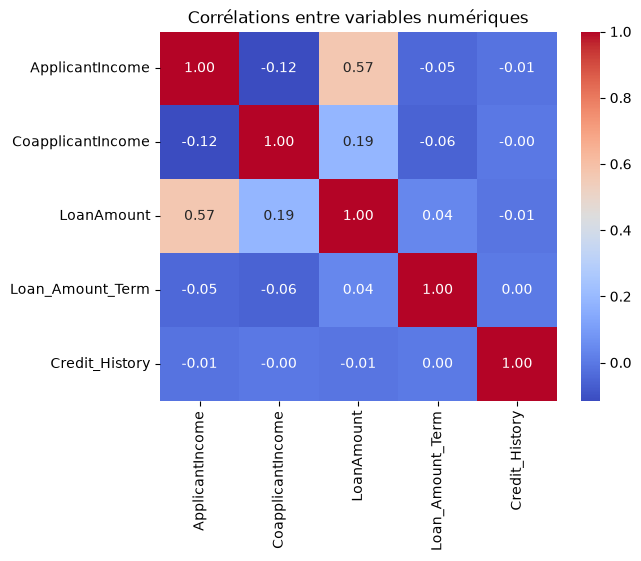

In [15]:
# Matrice de corrélation entre variables numériques, affichée sous forme de heatmap
df_corr = df.corr(numeric_only=True)
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélations entre variables numériques")
plt.show()


## 3. Prétraitement (sans fuite de données)

Règle d'or (déjà vue dans nb_02) : **on sépare train et test avant de calculer la moindre
statistique** (moyenne/médiane pour les valeurs manquantes, écart-type pour le `StandardScaler`...).
Sinon des informations du jeu de test "fuitent" dans l'entraînement et les performances mesurées
sont trop optimistes.

**Choix de la cible** : comme le projet parle de "risque", on encode `y = 1` si le dossier a été
**refusé** (`Loan_Status == "N"`) et `y = 0` s'il a été accordé. Ainsi un **Faux Négatif** = un
dossier réellement risqué (y=1) prédit comme sûr (y=0) — exactement le cas à éviter pour un outil
de scoring crédit.


In [16]:
# Cible : 1 = prêt risqué/refusé, 0 = prêt sûr/accordé
y = (df['Loan_Status'] == 'N').astype(int)
# Variables explicatives : tout sauf la colonne cible
X = df.drop(columns=['Loan_Status'])

print("Distribution de la cible (1 = risque / refus) :")
y.value_counts()


Distribution de la cible (1 = risque / refus) :


Loan_Status
0    422
1    192
Name: count, dtype: int64

In [17]:
# Split AVANT de calculer la moindre statistique (médiane, mode, moyenne, écart-type...) pour éviter la fuite de données
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train :", X_train.shape, "| X_test :", X_test.shape)


X_train : (491, 11) | X_test : (123, 11)


### Valeurs manquantes

Comme dans nb_01 (`df.fillna(...)`), on remplace les valeurs manquantes numériques par la
**médiane** (plus robuste que la moyenne face aux revenus très élevés) et les valeurs manquantes
catégorielles par la **catégorie la plus fréquente**. Les statistiques (médiane, catégorie la plus
fréquente) sont calculées **uniquement sur `X_train`**, puis réutilisées telles quelles sur
`X_test`.


In [18]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Colonnes numériques : remplir les valeurs manquantes avec la médiane du TRAIN, appliquée au train et au test
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

# Credit_History est un indicateur (0 = pas d'historique, 1 = bon historique) : on remplit avec
# le mode du train (valeur la plus fréquente), pas avec une moyenne.
credit_history_mode = X_train['Credit_History'].mode()[0]
X_train['Credit_History'] = X_train['Credit_History'].fillna(credit_history_mode)
X_test['Credit_History'] = X_test['Credit_History'].fillna(credit_history_mode)

# Colonnes catégorielles : remplir les valeurs manquantes avec la catégorie la plus fréquente du train
for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Valeurs manquantes restantes (train) :", X_train.isnull().sum().sum())
print("Valeurs manquantes restantes (test) :", X_test.isnull().sum().sum())


Valeurs manquantes restantes (train) : 0
Valeurs manquantes restantes (test) : 0


### Encodage des variables catégorielles

Comme dans nb_01, on utilise `pd.get_dummies`. On encode `X_train` et `X_test` séparément puis on
aligne les colonnes du test sur celles du train (`reindex`) : ça évite qu'une catégorie présente
uniquement dans le test crée une colonne que le modèle n'a jamais vue à l'entraînement.


In [19]:
# Encoder les colonnes catégorielles (transformer chaque catégorie en sa propre colonne 0/1)
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

# S'assurer que le jeu de test a exactement les mêmes colonnes que le jeu d'entraînement
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Colonnes après encodage :", X_train_encoded.shape[1])
X_train_encoded.head()


Colonnes après encodage : 20


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
415,2995,0.0,60.0,360.0,1.0,True,False,True,False,True,False,False,False,True,False,True,False,False,False,True
26,2799,2253.0,122.0,360.0,1.0,False,True,False,True,True,False,False,False,True,False,True,False,False,True,False
394,3100,1400.0,113.0,360.0,1.0,False,True,False,True,False,False,True,False,True,False,True,False,False,False,True
584,2787,1917.0,146.0,360.0,0.0,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False
86,3333,2000.0,99.0,360.0,1.0,False,True,False,True,False,False,True,False,False,True,True,False,False,True,False


### Standardisation des variables numériques

Comme dans nb_02 : `fit_transform` sur le train, `transform` (sans réajuster) sur le test.


In [20]:
from sklearn.preprocessing import StandardScaler

# Ajuster (fit) le scaler uniquement sur le train, puis l'appliquer (transform) au train et au test
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

X_train_scaled.head()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
415,-0.380050,-0.609749,-0.992566,0.293874,1.0,True,False,True,False,True,False,False,False,True,False,True,False,False,False,True
26,-0.410240,0.259948,-0.258962,0.293874,1.0,False,True,False,True,True,False,False,False,True,False,True,False,False,True,False
394,-0.363876,-0.069325,-0.365453,0.293874,1.0,False,True,False,True,False,False,True,False,True,False,True,False,False,False,True
584,-0.412089,0.130246,0.025014,0.293874,0.0,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False
86,-0.327987,0.162285,-0.531105,0.293874,1.0,False,True,False,True,False,False,True,False,False,True,True,False,False,True,False


## 4. Entraînement de plusieurs modèles de classification

Comme dans nb_02, on entraîne chaque modèle séparément.


In [21]:
# Modèle 1 : K plus proches voisins (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [22]:
# Modèle 2 : Régression Logistique (modèle linéaire, donne des coefficients interprétables)
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [23]:
# Modèle 3 : Machine à vecteurs de support (SVM) à noyau linéaire
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled, y_train)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [24]:
# Modèle 4 : Arbre de Décision
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [25]:
# Modèle 5 : Random Forest (ensemble d'arbres de décision)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [26]:
# Calculer les prédictions sur le jeu de test pour chaque modèle, puis les regrouper dans un dictionnaire
y_pred_knn = knn.predict(X_test_scaled)
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_tree = tree.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

predictions = {
    "KNN": y_pred_knn,
    "Régression Logistique": y_pred_log_reg,
    "SVM (linéaire)": y_pred_svm,
    "Arbre de Décision": y_pred_tree,
    "Random Forest": y_pred_rf,
}


## 5. Évaluation orientée métier : priorité au rappel (minimiser les Faux Négatifs)

Rappel de la lecture métier :
- **Faux Négatif** = un dossier réellement risqué (y=1) que le modèle classe comme sûr (y=0).
  → CrediTrust accorderait un crédit à quelqu'un qui ne le remboursera probablement pas. **C'est
  le pire cas** : perte financière directe.
- **Faux Positif** = un bon dossier (y=0) classé comme risqué (y=1).
  → CrediTrust refuserait à tort un client fiable. Ennuyeux (manque à gagner) mais moins coûteux
  qu'un défaut de paiement.

On calcule les métriques exactement comme dans nb_02 (dictionnaire par métrique), mais avec
`pos_label=1` pour que précision/rappel/F1 portent bien sur la classe "risque" (classification
binaire, pas multi-classe comme les iris).


In [27]:
# Accuracy = part de prédictions correctes au total (peut être trompeuse si les classes sont déséquilibrées)
from sklearn.metrics import accuracy_score

accuracy_scores = {name: accuracy_score(y_test, y_pred) for name, y_pred in predictions.items()}
accuracy_scores


{'KNN': 0.7073170731707317,
 'Régression Logistique': 0.8130081300813008,
 'SVM (linéaire)': 0.8130081300813008,
 'Arbre de Décision': 0.6504065040650406,
 'Random Forest': 0.7804878048780488}

In [28]:
# Précision (classe risque) = parmi les prêts prédits "risqués", combien le sont vraiment ?
from sklearn.metrics import precision_score

precision_scores = {
    name: precision_score(y_test, y_pred, pos_label=1)
    for name, y_pred in predictions.items()
}
precision_scores


{'KNN': 0.5555555555555556,
 'Régression Logistique': 0.8571428571428571,
 'SVM (linéaire)': 0.8947368421052632,
 'Arbre de Décision': 0.4444444444444444,
 'Random Forest': 0.7037037037037037}

In [29]:
# Rappel (classe risque) = parmi les prêts réellement risqués, combien le modèle en a détecté ?
# C'est la métrique prioritaire pour CrediTrust : un rappel faible veut dire beaucoup de dossiers
# risqués manqués (Faux Négatifs).
from sklearn.metrics import recall_score

recall_scores = {
    name: recall_score(y_test, y_pred, pos_label=1)
    for name, y_pred in predictions.items()
}
recall_scores


{'KNN': 0.2631578947368421,
 'Régression Logistique': 0.47368421052631576,
 'SVM (linéaire)': 0.4473684210526316,
 'Arbre de Décision': 0.5263157894736842,
 'Random Forest': 0.5}

In [30]:
# F1-score (classe risque) = équilibre entre précision et rappel, utile pour éviter de choisir un
# modèle qui maximise le rappel juste en prédisant "risqué" pour presque tout le monde.
from sklearn.metrics import f1_score

f1_scores = {
    name: f1_score(y_test, y_pred, pos_label=1)
    for name, y_pred in predictions.items()
}
f1_scores


{'KNN': 0.35714285714285715,
 'Régression Logistique': 0.6101694915254238,
 'SVM (linéaire)': 0.5964912280701754,
 'Arbre de Décision': 0.4819277108433735,
 'Random Forest': 0.5846153846153846}

In [31]:
# Regrouper toutes les métriques dans un seul tableau, trié par rappel (priorité métier)
results = pd.DataFrame({
    "Accuracy": accuracy_scores,
    "Précision (risque)": precision_scores,
    "Rappel (risque)": recall_scores,
    "F1 (risque)": f1_scores,
})
results = results.sort_values("Rappel (risque)", ascending=False)
results


,Accuracy,Précision (risque),Rappel (risque),F1 (risque)
Arbre de Décision,0.650407,0.444444,0.526316,0.481928
Random Forest,0.780488,0.703704,0.500000,0.584615
Régression Logistique,0.813008,0.857143,0.473684,0.610169
SVM (linéaire),0.813008,0.894737,0.447368,0.596491
KNN,0.707317,0.555556,0.263158,0.357143


### Sélection des 3 meilleurs modèles

On a testé 5 modèles pour explorer plusieurs familles d'algorithmes, mais on ne va pas tous les
garder pour la suite : on **sélectionne les 3 qui ont le meilleur rappel sur la classe "risque"**
(la priorité métier), et seuls ces 3-là seront analysés en détail (matrices de confusion,
interprétabilité). Les 2 autres sont écartés car moins bons sur le critère qui compte le plus ici.


In [32]:
# Ne garder que les noms des 3 modèles avec le meilleur rappel (results est déjà trié)
top3_names = results.head(3).index.tolist()
print("3 modèles retenus (meilleur rappel sur la classe risque) :", top3_names)

# Dictionnaire pour retrouver un modèle entraîné à partir de son nom
fitted_models = {
    "KNN": knn,
    "Régression Logistique": log_reg,
    "SVM (linéaire)": svm,
    "Arbre de Décision": tree,
    "Random Forest": rf,
}


3 modèles retenus (meilleur rappel sur la classe risque) : ['Arbre de Décision', 'Random Forest', 'Régression Logistique']


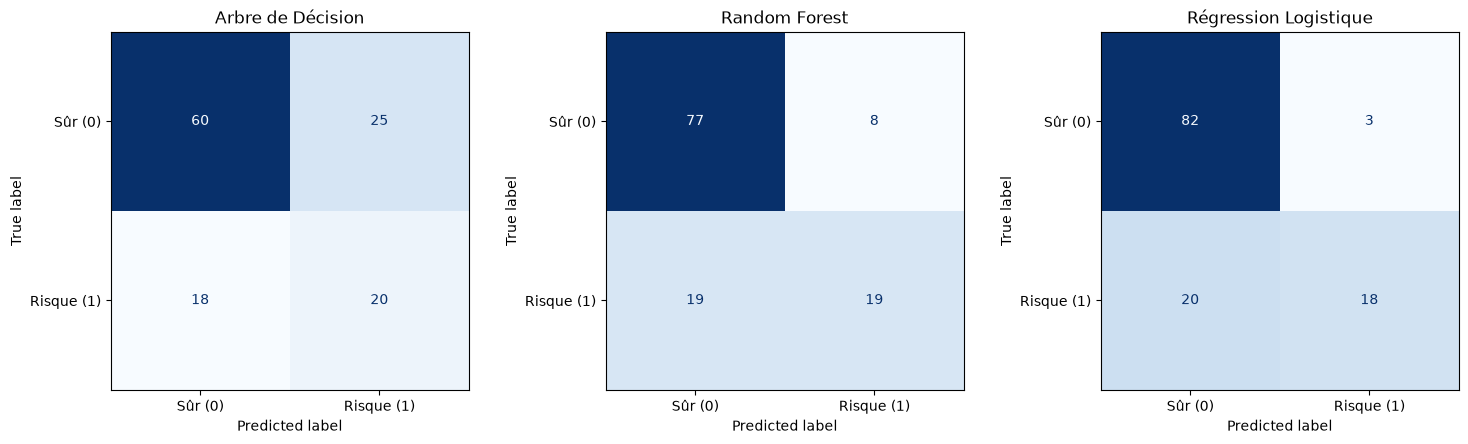

In [33]:
# Matrice de confusion pour chacun des 3 modèles retenus :
# lignes = classe réelle, colonnes = classe prédite
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, top3_names):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Sûr (0)", "Risque (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [34]:
# Choix final : le modèle avec le meilleur rappel parmi les 3 retenus (1re ligne du tableau trié)
best_model_name = top3_names[0]
print(f"Modèle optimal (meilleur rappel parmi les 3 retenus) : {best_model_name}")

from sklearn.metrics import classification_report
print(classification_report(
    y_test, predictions[best_model_name],
    target_names=["Sûr (0)", "Risque (1)"]
))


Modèle optimal (meilleur rappel parmi les 3 retenus) : Arbre de Décision
              precision    recall  f1-score   support

     Sûr (0)       0.77      0.71      0.74        85
  Risque (1)       0.44      0.53      0.48        38

    accuracy                           0.65       123
   macro avg       0.61      0.62      0.61       123
weighted avg       0.67      0.65      0.66       123



## 6. Interprétabilité des 3 modèles retenus

Comme dans nb_02 : coefficients pour un modèle linéaire (positif = augmente le risque, négatif =
le diminue), importances de variables pour un modèle à base d'arbres. On ne trace ça que pour les
3 modèles sélectionnés ci-dessus.


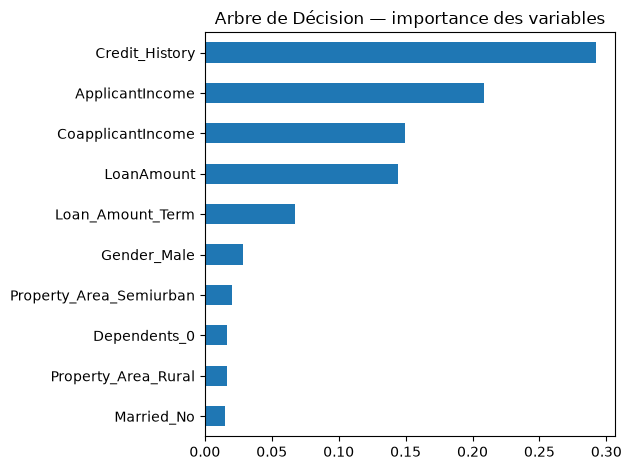

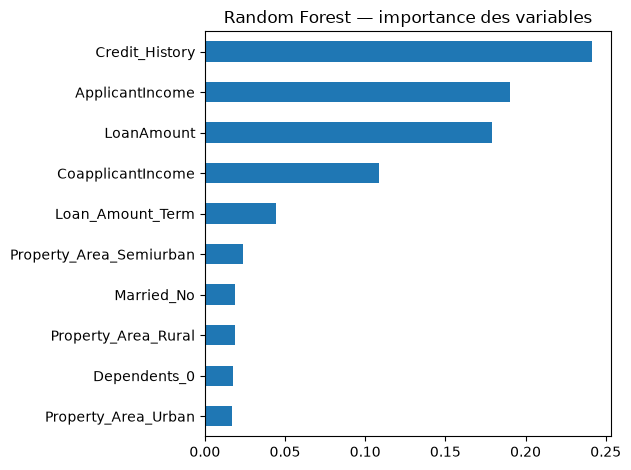

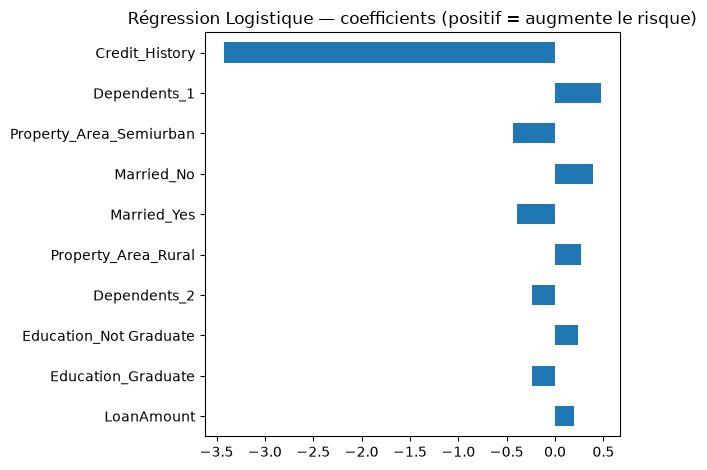

In [35]:
# Pour chacun des 3 modèles retenus, tracer ce qui est disponible :
# - coef_ pour les modèles linéaires (Régression Logistique, SVM linéaire)
# - feature_importances_ pour les modèles à base d'arbres (Arbre de Décision, Random Forest)
# KNN n'a ni l'un ni l'autre, donc il est ignoré.
for name in top3_names:
    model = fitted_models[name]

    if hasattr(model, "coef_"):
        values = pd.Series(model.coef_[0], index=X_train_scaled.columns)
        title = f"{name} — coefficients (positif = augmente le risque)"
    elif hasattr(model, "feature_importances_"):
        values = pd.Series(model.feature_importances_, index=X_train_scaled.columns)
        title = f"{name} — importance des variables"
    else:
        print(f"{name} : pas de coefficients ni d'importances directement exploitables (ex: KNN).")
        continue

    # Trier par valeur absolue pour que les effets les plus forts (positifs ou négatifs) apparaissent en premier
    values.sort_values(key=abs, ascending=False).head(10).plot(kind='barh')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


## 7. Conclusion

- **Facteur de risque dominant** : `Credit_History` (avoir déjà bien remboursé un crédit par le
  passé) ressort comme la variable la plus déterminante dans les 3 modèles retenus — cohérent avec
  l'EDA de la partie 2.
- **3 modèles retenus** : parmi les 5 testés, on a gardé les 3 avec le meilleur rappel sur la
  classe "risque" (partie 5) — c'est la métrique prioritaire ici, car laisser passer un dossier
  risqué coûte plus cher que refuser à tort un bon dossier.
- **Modèle optimal final** : celui des 3 avec le meilleur rappel (affiché en partie 5).
- **Limite du jeu de données** : `Loan_Status` reflète une décision d'octroi passée (accordé/
  refusé par un processus historique), pas un vrai défaut de paiement constaté. Le modèle apprend
  donc à reproduire les critères de décision historiques, pas directement le risque réel de
  défaut — un vrai projet CrediTrust nécessiterait un historique de remboursement/défaut pour
  affiner ce point.
